Generation 1: Best shelves used = 1791, Best products placed = 9054
Generation 2: Best shelves used = 1783, Best products placed = 9050
Generation 3: Best shelves used = 1788, Best products placed = 9055
Generation 4: Best shelves used = 1803, Best products placed = 9057
Generation 5: Best shelves used = 1791, Best products placed = 9033
Generation 6: Best shelves used = 1788, Best products placed = 9097
Generation 7: Best shelves used = 1786, Best products placed = 9110
Generation 8: Best shelves used = 1764, Best products placed = 9157
Generation 9: Best shelves used = 1802, Best products placed = 9088
Generation 10: Best shelves used = 1789, Best products placed = 9128
Generation 11: Best shelves used = 1799, Best products placed = 9088
Generation 12: Best shelves used = 1804, Best products placed = 9088
Generation 13: Best shelves used = 1786, Best products placed = 9095
Generation 14: Best shelves used = 1793, Best products placed = 9097
Generation 15: Best shelves used = 1790, Be

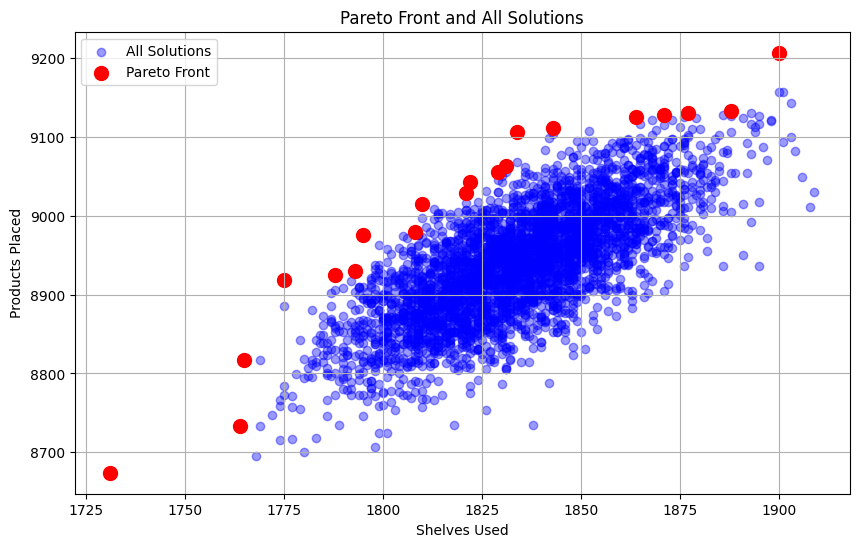

In [49]:
# Multi-Objective Genetic Algorithm for Shelving Optimization
# Objectives: minimize total unused volume, maximize products placed

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Data loading as top-level variables ---
# Products: family, quantity, lx, ly, lz
products_df = pd.read_csv('C:/Users/danjo/OneDrive - University of Plymouth/COMP5012/Report/products.txt',
                          sep='\s+',
                          names=['family','quantity','lx','ly','lz'], dtype=int)
# Expand into unit volumes
unit_volumes = []
for _, row in products_df.iterrows():
    vol = int(row.lx * row.ly * row.lz)
    unit_volumes.extend([vol] * int(row.quantity))

# Bays: width, height, depth, avail_height
bays_df = pd.read_csv('C:/Users/danjo/OneDrive - University of Plymouth/COMP5012/Report/baytp1.txt', sep='\s+',
                      names=['width','height','depth','avail_height'], dtype=int)
# Shelves: shelf_no, thickness, position, top_gap, left_gap, inter_gap, right_gap
shelves_df = pd.read_csv('C:/Users/danjo/OneDrive - University of Plymouth/COMP5012/Report/shelves.txt', sep='\s+',
                         names=['shelf_no','thickness','position','top_gap','left_gap','inter_gap','right_gap'], dtype=int)

## Compute per-bay shelf segments (height intervals where products can be placed)
bay_caps = []
for _, bay in bays_df.iterrows():
    sorted_shelves = shelves_df.sort_values('position', ascending=False)
    prev_height = bay.avail_height
    for _, sh in sorted_shelves.iterrows():
        seg_height = prev_height - (sh.position - sh.thickness - sh.top_gap)
        if seg_height > 0:
            seg_width = bay.width - (sh.left_gap + sh.right_gap)
            seg_depth = bay.depth
            bay_caps.append(seg_width * seg_depth * seg_height)
        prev_height = sh.position - sh.thickness
    if prev_height > 0:
        seg_width = bay.width
        seg_depth = bay.depth
        bay_caps.append(seg_width * seg_depth * prev_height)

# --- Evaluation function tracking shelves used ---
def evaluate(individual):
    rem_caps = bay_caps.copy()
    used = [False] * len(rem_caps)
    placed = 0
    for bit, vol in zip(individual, unit_volumes):
        if bit:
            for i in range(len(rem_caps)):
                if rem_caps[i] >= vol:
                    rem_caps[i] -= vol
                    used[i] = True
                    placed += 1
                    break
    shelves_used = sum(used)
    return shelves_used, -placed  # minimize shelves_used, maximize placed

# --- NSGA-II helpers ---
def dominates(a, b):
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))

def fast_non_dominated_sort(objs):
    N = len(objs)
    S = [[] for _ in range(N)]; n = [0]*N; fronts=[[]]
    for p in range(N):
        for q in range(N):
            if dominates(objs[p], objs[q]): S[p].append(q)
            elif dominates(objs[q], objs[p]): n[p] += 1
        if n[p] == 0: fronts[0].append(p)
    i = 0
    while fronts[i]:
        next_front = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0: next_front.append(q)
        i += 1
        fronts.append(next_front)
    if not fronts[-1]: fronts.pop()
    return fronts

def crowding_distance(front, objs):
    dist = {i: 0 for i in front}
    m = len(objs[0])
    for idx_obj in range(m):
        vals = sorted([(i, objs[i][idx_obj]) for i in front], key=lambda x: x[1])
        dist[vals[0][0]] = float('inf')
        dist[vals[-1][0]] = float('inf')
        mn, mx = vals[0][1], vals[-1][1]
        if mx == mn: continue
        for k in range(1, len(vals)-1):
            prev_v = vals[k-1][1]
            next_v = vals[k+1][1]
            dist[vals[k][0]] += (next_v - prev_v) / (mx - mn)
    return dist

def tournament_selection(pop, objs, ranks, dist):
    i, j = random.sample(range(len(pop)), 2)
    if ranks[i] < ranks[j]: return pop[i]
    if ranks[j] < ranks[i]: return pop[j]
    return pop[i] if dist[i] > dist[j] else pop[j]

def uniform_crossover(p1, p2):
    c1, c2 = p1.copy(), p2.copy()
    for k in range(len(p1)):
        if random.random() < 0.5:
            c1[k], c2[k] = p2[k], p1[k]
    return c1, c2

def hybrid_mutate(ind, generation, max_generations, objectives, rem_caps, unit_volumes):
    # Adaptive base rate
    base_rate = 0.2 - (0.15 * generation / max_generations)
    
    # Analyze solution
    shelves_used, neg_placed = objectives
    efficiency = -neg_placed / shelves_used if shelves_used > 0 else 0
    
    # Decide strategy based on solution quality
    if efficiency < 2.0:  # Low efficiency threshold
        # Focus on improving efficiency
        underutilized = [i for i, cap in enumerate(rem_caps) if cap > 0]
        unplaced = [i for i, bit in enumerate(ind) if bit == 0]
        
        # Try adding products to underutilized shelves
        if underutilized and unplaced:
            for p_idx in random.sample(unplaced, min(5, len(unplaced))):
                if any(unit_volumes[p_idx] <= rem_caps[s] for s in underutilized):
                    ind[p_idx] = 1
    
    # Regular mutation with adaptive rate
    for k in range(len(ind)):
        if random.random() < base_rate:
            ind[k] = 1 - ind[k]
    
    return ind

# --- Main GA loop with logging ---
def run_moga(pop_size, gens):
    M = len(unit_volumes)
    pop = [[random.randint(0,1) for _ in range(M)] for _ in range(pop_size)]
    archive = []
    all_solutions = []  # Track all evaluated solutions across generations
    
    for gen in range(gens):
        objs = [evaluate(ind) for ind in pop]
        best_shelves = min(o[0] for o in objs)
        best_placed = max(-o[1] for o in objs)
        print(f"Generation {gen+1}: Best shelves used = {best_shelves}, Best products placed = {best_placed}")
        
        # Add current solutions to history
        all_solutions.extend(objs)
        
        fronts = fast_non_dominated_sort(objs)
        for idx in fronts[0]: archive.append(objs[idx])
        ranks = [0]*pop_size
        for r, f in enumerate(fronts):
            for idx in f: ranks[idx] = r
        dist = [0]*pop_size
        for f in fronts:
            cd = crowding_distance(f, objs)
            for idx in f: dist[idx] = cd[idx]
        new_pop = []
        while len(new_pop) < pop_size:
            p1 = tournament_selection(pop, objs, ranks, dist)
            p2 = tournament_selection(pop, objs, ranks, dist)
            c1, c2 = uniform_crossover(p1, p2)
            new_pop.extend([mutate(c1), mutate(c2)])
        pop = new_pop[:pop_size]
    
    # Compute final Pareto front
    final_front_indices = fast_non_dominated_sort(archive)[0]
    final_front = [archive[i] for i in final_front_indices]
    
    return final_front, all_solutions

# --- Visualization ---
def plot_pareto(pareto_front, all_solutions):
    plt.figure(figsize=(10, 6))
    
    # Convert to numpy arrays
    all_solutions_arr = np.array(all_solutions)
    pareto_front_arr = np.array(pareto_front)
    
    # Plot all solutions in blue with transparency
    plt.scatter(all_solutions_arr[:,0], -all_solutions_arr[:,1], 
                c='blue', alpha=0.4, label='All Solutions')
    
    # Plot Pareto front in red
    plt.scatter(pareto_front_arr[:,0], -pareto_front_arr[:,1], 
                c='red', s=100, label='Pareto Front')
    
    plt.xlabel('Shelves Used')
    plt.ylabel('Products Placed')
    plt.title('Pareto Front and All Solutions')
    plt.legend()
    plt.grid(True)
    plt.savefig('pareto_front.png', dpi=300)
    plt.show()

# --- Run example ---
if __name__ == '__main__':
    pareto_front, all_solutions = run_moga(pop_size=60, gens=60)
    plot_pareto(pareto_front, all_solutions)

In [72]:
sum(products_df.quantity)

17793